In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\test.tsv", sep='\t')
df

,Unnamed: 0,title,text,subject,date,label
0,8104,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,7467,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,9473,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,276,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,19274,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...,...
8262,5469,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,5079,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,20425,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,22063,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0


In [3]:
test_data = df.drop(df.columns[0], axis=1)
test_data

,title,text,subject,date,label
0,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...
8262,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      3983

    accuracy                           0.99      8267
   macro avg       0.99      0.99      0.99      8267
weighted avg       0.99      0.99      0.99      8267

Accuracy: 0.9901
Precision: 0.9892
Recall: 0.9902
F1 Score: 0.9897
AUC-ROC: 0.9996


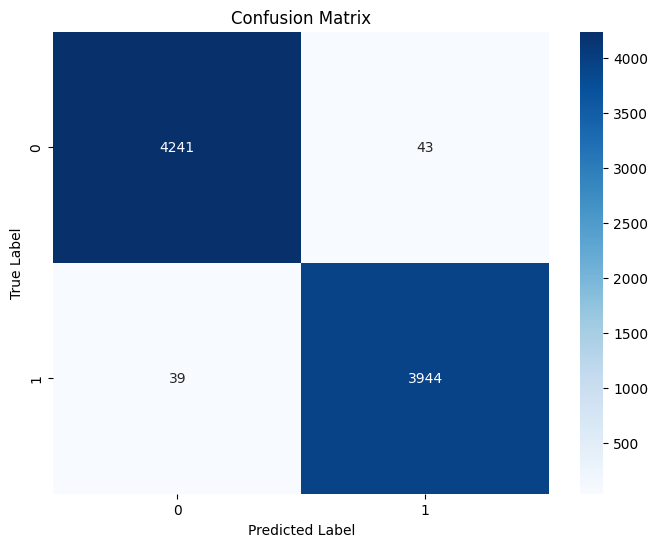

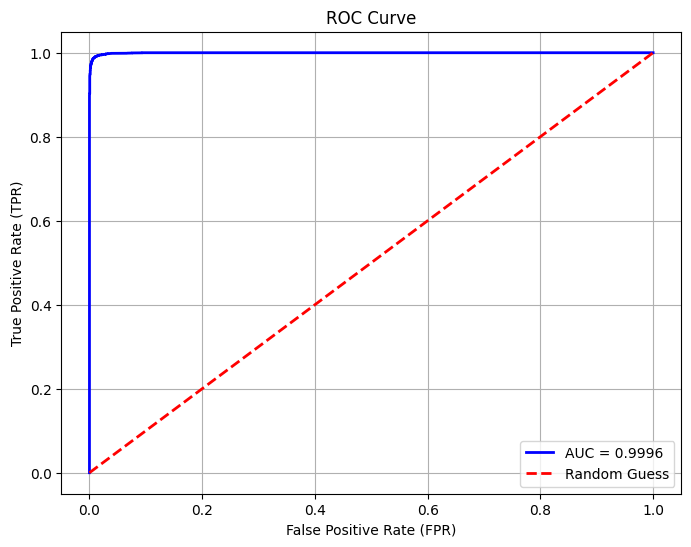

In [4]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, 
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Define clickbait and sensational keywords
clickbait_keywords = [
    'shocking', 'exclusive', 'breaking', 'urgent', 'warning',
    'incredible', 'unbelievable', 'miracle', 'secret', 'banned',
    'revolutionary', 'mind-blowing', 'you won\'t believe',
    'sensational', 'amazing', 'stunning', 'viral', 'exposed',
    'jaw-dropping', 'must see', 'conspiracy', 'scandal'
]

def calculate_keyword_density(text, keywords):
    if pd.isna(text):
        return 0

    text = text.lower()
    word_count = len(text.split())
    if word_count == 0:
        return 0

    keyword_count = sum(text.count(keyword.lower()) for keyword in keywords)
    return keyword_count / word_count

def create_keyword_features(df, tfidf_title=None, tfidf_text=None):
    features = pd.DataFrame(index=df.index)

    # Calculate keyword densities
    features['title_keyword_density'] = df['title'].apply(
        lambda x: calculate_keyword_density(x, clickbait_keywords)
    )

    features['text_keyword_density'] = df['text'].apply(
        lambda x: calculate_keyword_density(x, clickbait_keywords)
    )

    # Create TF-IDF features
    title_features = tfidf_title.transform(df['title'].fillna(''))
    text_features = tfidf_text.transform(df['text'].fillna(''))

    # Convert to DataFrame
    title_df = pd.DataFrame(
        title_features.toarray(),
        columns=[f'title_tfidf_{i}' for i in range(title_features.shape[1])],
        index=df.index
    )

    text_df = pd.DataFrame(
        text_features.toarray(),
        columns=[f'text_tfidf_{i}' for i in range(text_features.shape[1])],
        index=df.index
    )

    # Combine all features
    features = pd.concat([features, title_df, text_df], axis=1)
    return features

# Load models for sentiment analysis
def load_sentiment_models():
    with open(r'C:\Users\HP\OneDrive\Documents\jag_vscode\random_forest_model.pkl', 'rb') as f:
        sentiment_model = pickle.load(f)
    with open(r'C:\Users\HP\OneDrive\Documents\jag_vscode\tfidf_vectorizer.pkl', 'rb') as f:
        sentiment_vectorizer = pickle.load(f)
    return sentiment_model, sentiment_vectorizer

# Load models for keyword density analysis
def load_keyword_models():
    with open(r'C:\Users\HP\OneDrive\Documents\jag_keyword\models\rf_classifier.pkl', 'rb') as f:
        keyword_model = pickle.load(f)
    with open(r'C:\Users\HP\OneDrive\Documents\jag_keyword\models\tfidf_title_vectorizer.pkl', 'rb') as f:
        tfidf_title_vectorizer = pickle.load(f)
    with open(r'C:\Users\HP\OneDrive\Documents\jag_keyword\models\tfidf_text_vectorizer.pkl', 'rb') as f:
        tfidf_text_vectorizer = pickle.load(f)
    return keyword_model, tfidf_title_vectorizer, tfidf_text_vectorizer

# Load models for linguistic features
def load_linguistic_models():
    model_path = r'C:\Users\HP\OneDrive\Documents\jag_linguistics\fake_news_model_updated.pkl'
    vectorizer_path = r'C:\Users\HP\OneDrive\Documents\jag_linguistics\tfidf_vectorizer_updated.pkl'
    model = joblib.load(model_path)
    tfidf_vectorizer = joblib.load(vectorizer_path)
    return model, tfidf_vectorizer

# Length-Based Fake News Detector
class LengthBasedFakeNewsDetector:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        
    @classmethod
    def load_model(cls, filepath):
        """Load a trained model and scaler from a pickle file"""
        with open(filepath, 'rb') as f:
            model_components = pickle.load(f)
        
        detector = cls()
        detector.model = model_components['model']
        detector.scaler = model_components['scaler']
        return detector
        
    def extract_length_features(self, df):
        """Extract length-based features from text"""
        features = pd.DataFrame()
        
        # Title-based features
        features['title_char_count'] = df['title'].str.len()
        features['title_word_count'] = df['title'].str.split().str.len()
        features['title_avg_word_length'] = features['title_char_count'] / features['title_word_count']
        
        # Text-based features
        features['text_char_count'] = df['text'].str.len()
        features['text_word_count'] = df['text'].str.split().str.len()
        features['text_avg_word_length'] = features['text_char_count'] / features['text_word_count']
        
        # Additional features
        features['text_to_title_ratio'] = features['text_word_count'] / features['title_word_count']
        features['char_to_word_ratio'] = features['text_char_count'] / features['text_word_count']
        
        return features
        
    def predict(self, test_data):
        """Make predictions on test data"""
        # Extract features
        X = self.extract_length_features(test_data)
        
        # Scale features
        X_scaled = self.scaler.transform(X)
        
        # Make predictions
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled)[:, 1]
        
        return predictions, probabilities
        
    def evaluate(self, test_data, final_predictions, combined_predictions):
        """Evaluate model performance"""
        true_labels = test_data['label']

        print("\nClassification Report:")
        print(classification_report(true_labels, final_predictions))

        # Compute metrics
        accuracy = accuracy_score(true_labels, final_predictions)
        precision = precision_score(true_labels, final_predictions)
        recall = recall_score(true_labels, final_predictions)
        f1 = f1_score(true_labels, final_predictions)
        auc = roc_auc_score(true_labels, combined_predictions)

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"AUC-ROC: {auc:.4f}")

        # Plot confusion matrix
        cm = confusion_matrix(true_labels, final_predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

        # Plot ROC curve
        fpr, tpr, thresholds = roc_curve(true_labels, combined_predictions)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc:.4f}')
        plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Random Guess')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()

# Combine predictions using weighted averages
def predict_fake_news(test_data):
    # Load all models
    sentiment_model, sentiment_vectorizer = load_sentiment_models()
    keyword_model, tfidf_title_vectorizer, tfidf_text_vectorizer = load_keyword_models()
    linguistic_model, linguistic_vectorizer = load_linguistic_models()
    length_based_detector = LengthBasedFakeNewsDetector.load_model(r"C:\Users\HP\OneDrive\Documents\jag_length\my_model.pkl")
    
    # Generate features for sentiment analysis
    sentiment_features = sentiment_vectorizer.transform(test_data['text'])
    sentiment_predictions = sentiment_model.predict_proba(sentiment_features)[:, 1]
    
    # Generate features for keyword density analysis
    keyword_features = create_keyword_features(test_data, tfidf_title_vectorizer, tfidf_text_vectorizer)
    keyword_predictions = keyword_model.predict_proba(keyword_features)[:, 1]
    
    # Generate features for linguistic model
    linguistic_features = linguistic_vectorizer.transform(test_data['text'])
    linguistic_predictions = linguistic_model.predict_proba(linguistic_features)[:, 1]
    
    # Generate features for length-based model
    length_predictions, length_probabilities = length_based_detector.predict(test_data)
    
    # Combine predictions with weighted average
    weight_sentiment = 0.3
    weight_keyword = 0.3
    weight_linguistic = 0.2
    weight_length = 0.2
    
    combined_predictions = (weight_sentiment * sentiment_predictions +
                            weight_keyword * keyword_predictions +
                            weight_linguistic * linguistic_predictions +
                            weight_length * length_probabilities)
    
    # Final predictions based on the combined probabilities
    final_predictions = (combined_predictions >= 0.5).astype(int)

    # Evaluate the model
    length_based_detector.evaluate(test_data, final_predictions, combined_predictions)

# Assuming `test_data` is your dataframe with 'text', 'title', and 'label'
predict_fake_news(test_data)


In [5]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

class LengthBasedFakeNewsDetector:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        
    @classmethod
    def load_model(cls, filepath):
        """Load a trained model and scaler from a joblib file"""
        model_components = joblib.load(filepath)
        
        detector = cls()
        detector.model = model_components['model']
        detector.scaler = model_components['scaler']
        return detector
        
    def extract_length_features(self, df):
        """Extract length-based features from text"""
        features = pd.DataFrame()
        
        # Title-based features
        features['title_char_count'] = df['title'].str.len()
        features['title_word_count'] = df['title'].str.split().str.len()
        features['title_avg_word_length'] = features['title_char_count'] / features['title_word_count']
        
        # Text-based features
        features['text_char_count'] = df['text'].str.len()
        features['text_word_count'] = df['text'].str.split().str.len()
        features['text_avg_word_length'] = features['text_char_count'] / features['text_word_count']
        
        # Additional features
        features['text_to_title_ratio'] = features['text_word_count'] / features['title_word_count']
        features['char_to_word_ratio'] = features['text_char_count'] / features['text_word_count']
        
        return features
        
    def predict(self, test_data):
        """Make predictions on test data"""
        # Extract features
        X = self.extract_length_features(test_data)
        
        # Scale features
        X_scaled = self.scaler.transform(X)
        
        # Make predictions
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled)[:, 1]
        
        return predictions, probabilities
        
    def evaluate(self, test_data, final_predictions, combined_predictions):
        """Evaluate model performance"""
        true_labels = test_data['label']

        print("\nClassification Report:")
        print(classification_report(true_labels, final_predictions))

        # Compute metrics
        accuracy = accuracy_score(true_labels, final_predictions)
        precision = precision_score(true_labels, final_predictions)
        recall = recall_score(true_labels, final_predictions)
        f1 = f1_score(true_labels, final_predictions)
        auc = roc_auc_score(true_labels, combined_predictions)

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"AUC-ROC: {auc:.4f}")

        # Plot confusion matrix
        cm = confusion_matrix(true_labels, final_predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

        # Plot ROC curve
        fpr, tpr, thresholds = roc_curve(true_labels, combined_predictions)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc:.4f}')
        plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Random Guess')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()

# Assuming integrated_model has the following method and usage
class IntegratedFakeNewsModel:
    def __init__(self):
        self.length_based_detector = None
        self.keyword_model = None
        self.linguistic_model = None

    def load_keyword_models(self, rf_model_path, tfidf_title_vectorizer_path, tfidf_text_vectorizer_path):
        """Load keyword-based models"""
        self.keyword_model = joblib.load(rf_model_path)
        self.tfidf_title_vectorizer = joblib.load(tfidf_title_vectorizer_path)
        self.tfidf_text_vectorizer = joblib.load(tfidf_text_vectorizer_path)

    def load_linguistic_models(self, linguistic_model_path, tfidf_vectorizer_path):
        """Load linguistic models"""
        self.linguistic_model = joblib.load(linguistic_model_path)
        self.tfidf_vectorizer = joblib.load(tfidf_vectorizer_path)

    def load_length_based_detector(self, length_model_path):
        """Load length-based fake news detector"""
        self.length_based_detector = LengthBasedFakeNewsDetector.load_model(length_model_path)
        
    def save(self, model_save_path):
        """Save the integrated model"""
        joblib.dump(self, model_save_path)

# Load integrated model and other models
integrated_model = IntegratedFakeNewsModel()
integrated_model.load_keyword_models(r'C:\Users\HP\OneDrive\Documents\jag_keyword\models\rf_classifier.pkl',
                                     r'C:\Users\HP\OneDrive\Documents\jag_keyword\models\tfidf_title_vectorizer.pkl', 
                                     r'C:\Users\HP\OneDrive\Documents\jag_keyword\models\tfidf_text_vectorizer.pkl')
integrated_model.load_linguistic_models(r'C:\Users\HP\OneDrive\Documents\jag_linguistics\fake_news_model_updated.pkl', 
                                       r'C:\Users\HP\OneDrive\Documents\jag_linguistics\tfidf_vectorizer_updated.pkl')
integrated_model.load_length_based_detector(r'C:\Users\HP\OneDrive\Documents\jag_length\my_model.pkl')

# Save the integrated model
integrated_model.save(r'C:\Users\HP\OneDrive\Documents\integrated\multiobjective\integrated_model.pkl')


In [6]:
import joblib
import pandas as pd

# Load the integrated model
integrated_model_path = r'C:\Users\HP\OneDrive\Documents\integrated\multiobjective\integrated_model.pkl'
integrated_model = joblib.load(integrated_model_path)

# Now make predictions with the model
length_based_predictions, length_based_probabilities = integrated_model.length_based_detector.predict(test_data)

# Create a DataFrame with predictions
predictions_df = pd.DataFrame({
    'title': test_data['title'],
    'text': test_data['text'],
    'predictions': length_based_predictions,
    'probabilities': length_based_probabilities
})

# Optionally, save predictions to a CSV for further analysis
predictions_df.to_csv('predictions.csv', index=False)

# Print the first few rows of the predictions
print(predictions_df.head())


                                               title  \
0  Conservatives Will HATE What Donald Trump Just...   
1  Trump victory may create new tension between U...   
2  WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...   
3  Democratic Senator Franken to resign: CNN, cit...   
4  GANG OF DOMESTIC TERRORISTS Violently Attack L...   

                                                text  predictions  \
0  Donald Trump isn t exactly a stranger to makin...            0   
1  Donald Trump’s U.S. election victory may creat...            1   
2  A couple of quick questions come to mind when ...            0   
3  U.S. Democratic Senator Al Franken will announ...            1   
4  ***WARNING*** Violence is graphic***This Trump...            0   

   probabilities  
0           0.40  
1           0.69  
2           0.00  
3           0.99  
4           0.00  


In [7]:
import joblib
import pandas as pd

# Load the integrated model
integrated_model_path = r'C:\Users\HP\OneDrive\Documents\integrated\multiobjective\integrated_model.pkl'
integrated_model = joblib.load(integrated_model_path)

# Assuming test_data is already a DataFrame containing the 'title' and 'text' columns
# Example:
# test_data = pd.DataFrame({
#     'title': ['Example Title 1', 'Example Title 2'],
#     'text': ['Example text 1', 'Example text 2']
# })

# Make predictions with the model
length_based_predictions, length_based_probabilities = integrated_model.length_based_detector.predict(test_data)

# Create a DataFrame with predictions
predictions_df = pd.DataFrame({
    'title': test_data['title'],
    'text': test_data['text'],
    'predictions': length_based_predictions,
    'probabilities': length_based_probabilities
})

# Save predictions in the desired format in result.txt with UTF-8 encoding
with open('result.txt', 'w', encoding='utf-8') as result_file:
    for index, row in predictions_df.iterrows():
        # Structure each record as '{input_data} {classification_data}'
        result = f"{{'title': '{row['title']}', 'text': '{row['text']}'}}, {{'predictions': {row['predictions']}, 'probabilities': {row['probabilities']}}}\n"
        result_file.write(result)

# Print the first few rows of the predictions for verification
print(predictions_df.head())


                                               title  \
0  Conservatives Will HATE What Donald Trump Just...   
1  Trump victory may create new tension between U...   
2  WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...   
3  Democratic Senator Franken to resign: CNN, cit...   
4  GANG OF DOMESTIC TERRORISTS Violently Attack L...   

                                                text  predictions  \
0  Donald Trump isn t exactly a stranger to makin...            0   
1  Donald Trump’s U.S. election victory may creat...            1   
2  A couple of quick questions come to mind when ...            0   
3  U.S. Democratic Senator Al Franken will announ...            1   
4  ***WARNING*** Violence is graphic***This Trump...            0   

   probabilities  
0           0.40  
1           0.69  
2           0.00  
3           0.99  
4           0.00  
